# Projection and time-dependent Leslie

11-Year Projection (2003-2013 Observed):
Baseline Leslie: Euclidean=0.1158, RMSE=0.0473
Time-dependent: Euclidean=0.0721, RMSE=0.0294

21-Year Projection (2013-2023 Observed):
Baseline Leslie: Euclidean=0.1571, RMSE=0.0641
Time-dependent: Euclidean=0.0810, RMSE=0.0331



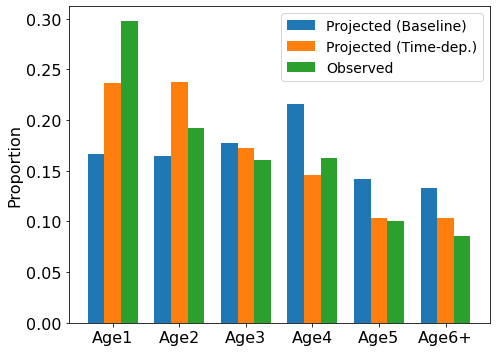

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load data
filename = "data.xlsx"
df_counts = pd.read_excel(filename, sheet_name="AllFemales", index_col=0)
df_tows = pd.read_excel(filename, sheet_name="TowCount", index_col=0)

df_counts = df_counts.sort_index()
df_tows = df_tows.sort_index()

# Compute CPUE
cpue = df_counts.div(df_tows['Tows'], axis=0)


# Initial condition: 1992–2002 average
x0 = cpue.loc[1992:2002].mean(axis=0).values
x0 = x0 / x0.sum()

# Observed for 11-year and 21-year projections
xobs_11 = cpue.loc[2003:2013].mean(axis=0).values
xobs_11 = xobs_11 / xobs_11.sum()

xobs_21 = cpue.loc[2013:2023].mean(axis=0).values
xobs_21 = xobs_21 / xobs_21.sum()

# Baseline Leslie matrix
L_base = np.array([
    [0.0, 0.036, 0.204, 0.255, 0.144, 0.118],
    [0.789, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.860, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.971, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.523, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.750, 0.0]
])


# Time-dependent Leslie parameters
F0 = L_base[0, 1:]
S0 = [L_base[1,0], L_base[2,1], L_base[3,2], L_base[4,3], L_base[5,4]]
beta = [0.00, 0.00, 0.001, 0.001, 0.001]
alpha = [0.02, 0.03, 0.03, 0.02, 0.02]

def make_leslie(t):
    F = np.array([0.0] + [max(0, F0[i]*(1-beta[i]*t)) for i in range(5)])
    S = np.array([0.0] + [max(0, S0[i]*(1-alpha[i]*t)) for i in range(5)])
    L = np.zeros((6,6))
    L[0,1:] = F[1:]
    for i in range(1,6):
        L[i,i-1] = S[i]
    return L

# Projection function
def project_population(x0, years):
    n_age = len(x0)
    x_base = np.zeros((years+1, n_age))
    x_time = np.zeros((years+1, n_age))
    x_base[0] = x0
    x_time[0] = x0
    for t in range(years):
        # baseline
        x_base[t+1] = L_base @ x_base[t]
        x_base[t+1] /= x_base[t+1].sum()
        # time-dependent
        x_time[t+1] = make_leslie(t) @ x_time[t]
        x_time[t+1] /= x_time[t+1].sum()
    return x_base, x_time


# 11-year and 21-year projections
x_base_11, x_time_11 = project_population(x0, 11)
x_base_21, x_time_21 = project_population(x0, 21)


# Compute RMSE and Euclidean distance
def compute_metrics(x_proj, x_obs):
    rmse = np.sqrt(np.mean((x_proj - x_obs)**2))
    euclid = np.linalg.norm(x_proj - x_obs)
    return rmse, euclid

rmse_base_11, euclid_base_11 = compute_metrics(x_base_11[-1], xobs_11)
rmse_time_11, euclid_time_11 = compute_metrics(x_time_11[-1], xobs_11)

rmse_base_21, euclid_base_21 = compute_metrics(x_base_21[-1], xobs_21)
rmse_time_21, euclid_time_21 = compute_metrics(x_time_21[-1], xobs_21)

print("11-Year Projection (2003-2013 Observed):")
print(f"Baseline Leslie: Euclidean={euclid_base_11:.4f}, RMSE={rmse_base_11:.4f}")
print(f"Time-dependent: Euclidean={euclid_time_11:.4f}, RMSE={rmse_time_11:.4f}\n")

print("21-Year Projection (2013-2023 Observed):")
print(f"Baseline Leslie: Euclidean={euclid_base_21:.4f}, RMSE={rmse_base_21:.4f}")
print(f"Time-dependent: Euclidean={euclid_time_21:.4f}, RMSE={rmse_time_21:.4f}\n")


# Plot comparison (21-year)
ages = ['Age1','Age2','Age3','Age4','Age5','Age6+']
x = np.arange(len(ages))
width = 0.25

plt.figure(figsize=(7,5))
plt.bar(x - width, x_base_21[-1], width, label='Projected (Baseline)')
plt.bar(x, x_time_21[-1], width, label='Projected (Time-dep.)')
plt.bar(x + width, xobs_21, width, label='Observed')
plt.xticks(x, ages, fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel('Proportion', fontsize=16)
#plt.title('Structure Comparison After 21-Year Projection', fontsize=16)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig("projection_comparison_barplot.pdf",bbox_inches="tight")
plt.savefig("projection_comparison_barplot.png", dpi=300)
plt.show()